# 29 — Correlation Heatmap

## Goal
To measure relationships between numeric sensor features using correlation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "raw" / "motionsense_raw.csv"
CLEAN_PATH = DATA_DIR / "processed" / "motionsense_clean.csv"
ML_READY_PATH = DATA_DIR / "processed" / "motionsense_ml_ready.csv"
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## Correlation
Correlation measures how strongly two numeric columns move together.

The value ranges from **-1** to **+1**:

- close to +1: strong positive relationship
- close to 0: weak relationship
- close to -1: strong negative relationship

In [2]:
df = pd.read_csv(CLEAN_PATH)

# Select a small set of important numeric columns.
features = [
    "acc_x", "acc_y", "acc_z",
    "gyro_x", "gyro_y", "gyro_z",
    "acc_magnitude", "gyro_magnitude"
]

# Calculate the correlation matrix.
corr = df[features].corr()
corr.round(2)

,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,acc_magnitude,gyro_magnitude
acc_x,1.00,0.01,0.01,0.06,0.06,0.08,0.04,0.06
acc_y,0.01,1.00,0.02,0.05,0.04,0.00,0.01,0.06
acc_z,0.01,0.02,1.00,0.25,-0.01,-0.02,0.91,0.27
gyro_x,0.06,0.05,0.25,1.00,-0.02,-0.04,0.47,0.95
gyro_y,0.06,0.04,-0.01,-0.02,1.00,0.05,-0.03,-0.04
gyro_z,0.08,0.00,-0.02,-0.04,0.05,1.00,-0.03,-0.04
acc_magnitude,0.04,0.01,0.91,0.47,-0.03,-0.03,1.00,0.51
gyro_magnitude,0.06,0.06,0.27,0.95,-0.04,-0.04,0.51,1.00


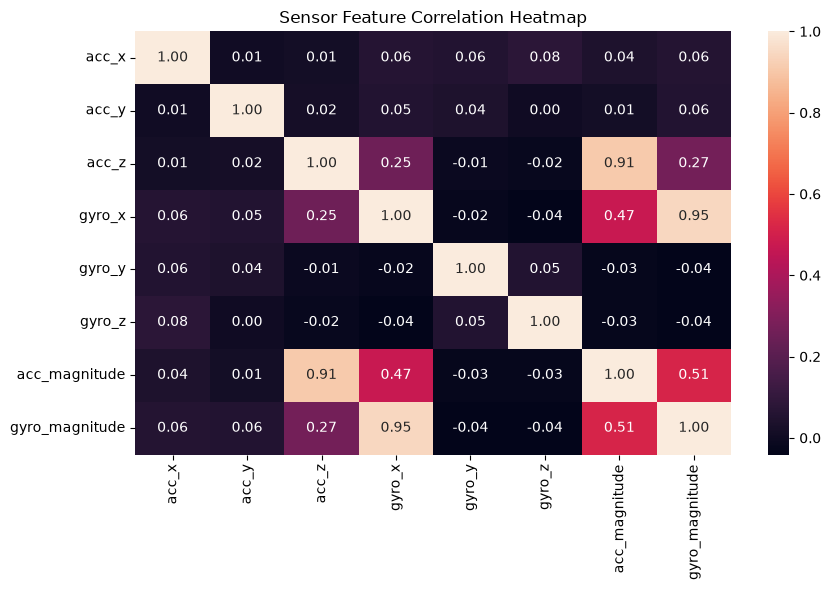

In [3]:
# Plot the correlation matrix as a heatmap.
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Sensor Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Summary
Correlation helps us identify features that move together and features that may be useful for prediction.